# HW 1 — Decision Tree

## Data file
Before running, upload `car.csv` (Car Evaluation dataset, includes a header row) to the notebook's working directory:
- **Google Colab**: click the folder icon in the left sidebar → upload icon → select `car.csv`. It will be available at `/content/car.csv` for that session (you'll need to re-upload if the runtime disconnects/resets).
- **Local Jupyter**: place `car.csv` in the same folder as this notebook file.

Make sure the filename/path in the `pd.read_csv(...)` call matches wherever you've placed the file.

## How to run
Restart the kernel and run all cells **top to bottom, in order**. Later cells depend on classes/functions defined earlier (`Node`, `DecisionTree`, `ExecuteDecisionTree`, `report_stats`, `plot_histograms`), so running out of order will cause errors.

## Reproducibility
`np.random.seed(42)` is set once at the top of `ExecuteDecisionTree`, so re-running from a fresh kernel reproduces the same sequence of splits and results. No fixed `random_state` is used inside the per-trial loop, since each of the 100 trials needs an independent random split.

## Configurable options
`ExecuteDecisionTree(use_gini=False, use_additional_criterion=False)`:
- `use_gini=True` — use Gini index instead of Information Gain (extra credit QE.1)
- `use_additional_criterion=True` — apply the 85%-majority-class pruning heuristic (extra credit QE.2)
- The function call for all the mentioned cases is already written. So, there is no need to explicitly change the parameter and re-run the cell.


In [1]:
#imports
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
from collections import Counter

In [2]:
df = pd.read_csv("car.csv")
print(np.unique(df['buying_price']))
print(np.unique(df['maintenance_price']))
print(np.unique(df['number_doors']))
print(np.unique(df['capacity']))
print(np.unique(df['luggage_boot_size']))
print(np.unique(df['safety_level']))
print(np.unique(df['class']))
df.head()

['high' 'low' 'medium' 'very_high']
['high' 'low' 'medium' 'very_high']
['5_or_more' 'four' 'three' 'two']
['5_or_more' 'four' 'two']
['large' 'medium' 'small']
['high' 'low' 'medium']
['acceptable' 'good' 'unacceptable' 'very_good']


,buying_price,maintenance_price,number_doors,capacity,luggage_boot_size,safety_level,class
0,very_high,very_high,two,two,small,low,unacceptable
1,very_high,very_high,two,two,small,medium,unacceptable
2,very_high,very_high,two,two,small,high,unacceptable
3,very_high,very_high,two,two,medium,low,unacceptable
4,very_high,very_high,two,two,medium,medium,unacceptable


In [3]:
#shuffle and split
def shuffle_and_split(df):
  df_shuffled = shuffle(df) #didn't use random_state as we need uniquely shuffled and split datasets for all each value of k

  X=df_shuffled.iloc[:,:-1]
  y=df_shuffled.iloc[:,-1]

  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
  return X_train, X_test, y_train, y_test

In [4]:
class Node:
  def __init__(self,
               information_gain = None,
               feature_index = None,
               majority_class=None,
               children = None,
               value = None):
    # conditional node
    self.information_gain = information_gain
    self.feature_index = feature_index
    self.majority_class = majority_class # for fallback -- if an instance with a new feature_value is found while testing which was not used to construct the decision tree
    self.children = children if children is not None else {}

    # leaf node
    self.value = value

In [5]:
class DecisionTree:
  def build_decision_tree(self, data, available_features, use_gini = False, use_additional_criterion = False):
    X, y = data[:,:-1], data[:,-1]
    majority_class = Counter(y).most_common(1)[0][0]
    majority_class_ratio = Counter(y)[majority_class] / len(y)

    if use_additional_criterion and majority_class_ratio >= 0.85:
      return Node(value = majority_class)

    if len(available_features) > 0 and len(np.unique(y))!=1:
      ideal_split = self.get_ideal_split(data, available_features, use_gini) #check how to decrease number of features

      if ideal_split["information_gain"] > 0:
        features_remaining = [feature for feature in available_features if feature != ideal_split["feature_index"]]

        for val in ideal_split["children"]:
          ideal_split["children"][val] = self.build_decision_tree(ideal_split["children"][val], features_remaining, use_gini, use_additional_criterion)

        return Node(information_gain = ideal_split["information_gain"],
                    feature_index = ideal_split["feature_index"],
                    majority_class = majority_class,
                    children = ideal_split["children"])

    return Node(value = majority_class)

  def get_ideal_split(self, data, available_features, use_gini = False):
    ideal_split = { "information_gain": -1, "feature_index": None, "children": {} }

    for feature_index in available_features:
      children = self.split_data(data, feature_index)

      if len(children)>1:
        parent_y = data[:, -1]
        children_y = [sub_data[:, -1] for sub_data in children.values()]

        information_gain = self.compute_information_gain(parent_y, children_y, use_gini)

        if information_gain > ideal_split['information_gain']:
          ideal_split['information_gain'] = information_gain
          ideal_split['feature_index'] = feature_index
          ideal_split['children'] = children

    return ideal_split

  def split_data(self, data, feature_index):
    vals = np.unique(data[:, feature_index])
    # split the dataset records for each unique value in the current feature (data[feature_index])
    return {val: data[data[:, feature_index] == val] for val in vals}

  def compute_information_gain(self, parent_y, children_y, use_gini = False):
    weights = [len(child_y) / len(parent_y) for child_y in children_y]

    if not use_gini:
      information_gain = self.get_entropy(parent_y) - (sum([weights[i] * self.get_entropy(children_y[i]) for i in range(len(children_y))]))
    else:
      information_gain = self.get_gini_index(parent_y) - (sum([weights[i] * self.get_gini_index(children_y[i]) for i in range(len(children_y))]))

    return information_gain

  def get_entropy(self, y):
    result = 0
    labels = np.unique(y)
    for label in labels:
      probability = len(y[y==label]) / len(y)
      result -= probability * np.log2(probability)
    return result

  def get_gini_index(self, y):
    result = 0
    labels = np.unique(y)
    for label in labels:
      probability = len(y[y==label]) / len(y)
      result += probability ** 2
    return 1-result

  def predict(self, X):
    X = np.array(X)
    preds = [self.predict_helper(row, self.root) for row in X]
    return preds

  def predict_helper(self, row, node):
    if node.value is not None:
      return node.value

    feature_value = row[node.feature_index]
    child = node.children.get(feature_value)

    if child is not None:
      return self.predict_helper(row, child)
    else:
      return node.majority_class


In [6]:
def ExecuteDecisionTree( use_gini = False, use_additional_criterion = False):
  decision_tree = DecisionTree()

  np.random.seed(42)
  train_accs = []
  test_accs = []
  for i in range(100):
    #shuffle and split dataset
    X_train, X_test, y_train, y_test = shuffle_and_split(df)

    #build decision tree
    data = np.concatenate((X_train, y_train.values.reshape(-1,1)), axis=1)
    number_of_features = X_train.shape[1]
    decision_tree.root = decision_tree.build_decision_tree(data, list(range(number_of_features)), use_gini, use_additional_criterion)

    train_preds = decision_tree.predict(X_train)
    train_acc = np.mean(train_preds == y_train) * 100

    test_preds = decision_tree.predict(X_test)
    test_acc = np.mean(test_preds == y_test) * 100

    train_accs.append(train_acc)
    test_accs.append(test_acc)

  return train_accs, test_accs

In [7]:
def plot_histograms(accuracies, title):
  plt.hist(accuracies, bins=30, color='skyblue', edgecolor='black')
  plt.xlabel('Accuracy')
  plt.ylabel('Frequency')
  plt.title(title)
  plt.show()

In [8]:
def get_stats(accuracies, title):
  mean_acc = np.mean(accuracies)
  std_dev_acc = np.std(accuracies)
  print(f"{title}")
  print(f"Mean Accuracy: {mean_acc:.2f}")
  print(f"Standard Deviation of Accuracy: {std_dev_acc:.2f}")

In [9]:
train_accs, test_accs = ExecuteDecisionTree()

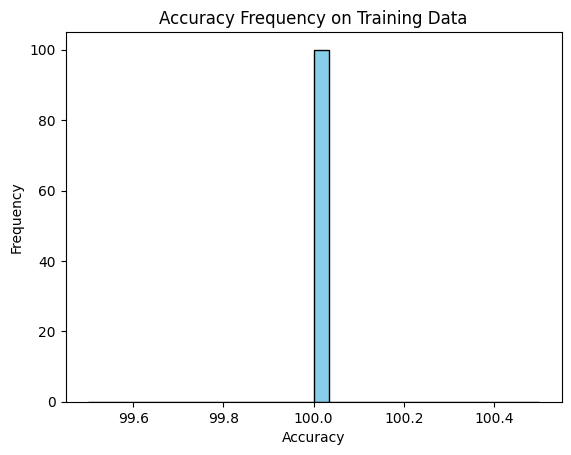

Accuracy - Training Data
Mean Accuracy: 100.00
Standard Deviation of Accuracy: 0.00


In [10]:
plot_histograms(train_accs, 'Accuracy Frequency on Training Data')
mean_acc = get_stats(train_accs, "Accuracy - Training Data")

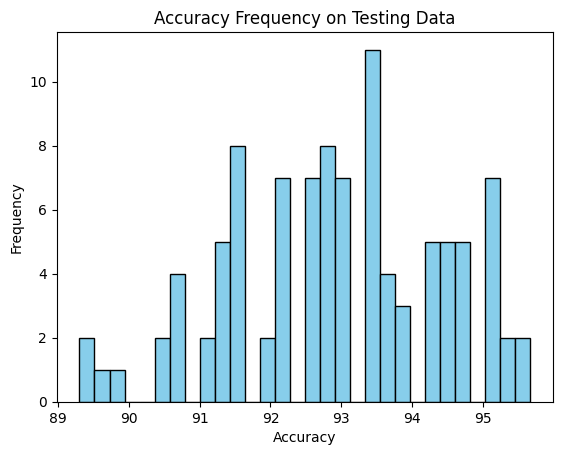

Accuracy - Testing Data
Mean Accuracy: 92.92
Standard Deviation of Accuracy: 1.50


In [11]:
plot_histograms(test_accs, 'Accuracy Frequency on Testing Data')
mean_acc = get_stats(test_accs, "Accuracy - Testing Data")

**EXTRA CREDIT QUESTIONS**

In [12]:
#Using GINI Index
train_accs_gini, test_accs_gini = ExecuteDecisionTree(use_gini = True)

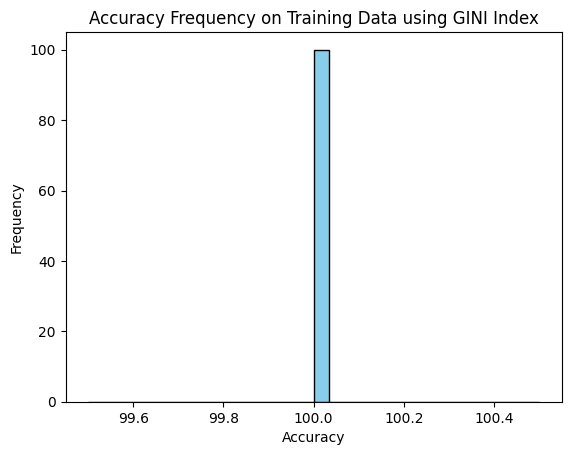

Accuracy - Training Data using GINI Index
Mean Accuracy: 100.00
Standard Deviation of Accuracy: 0.00


In [13]:
plot_histograms(train_accs_gini, 'Accuracy Frequency on Training Data using GINI Index')
get_stats(train_accs_gini, "Accuracy - Training Data using GINI Index")

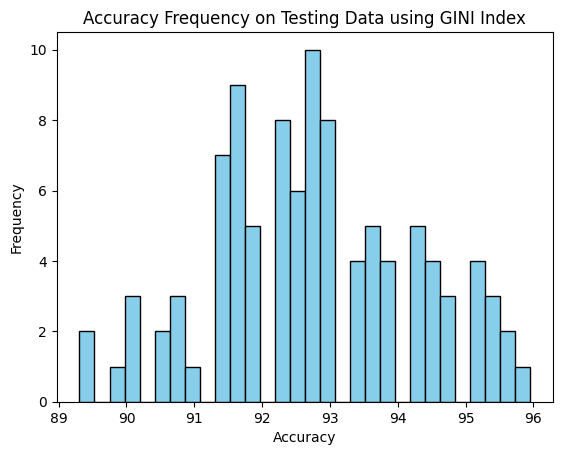

Accuracy - Testing Data using GINI Index
Mean Accuracy: 92.76
Standard Deviation of Accuracy: 1.51


In [14]:
plot_histograms(test_accs_gini, 'Accuracy Frequency on Testing Data using GINI Index')
get_stats(test_accs_gini, "Accuracy - Testing Data using GINI Index")

In [15]:
# Using another stopping heuristic
train_accs_additional_criterion, test_accs_additional_criterion = ExecuteDecisionTree(use_additional_criterion = True)


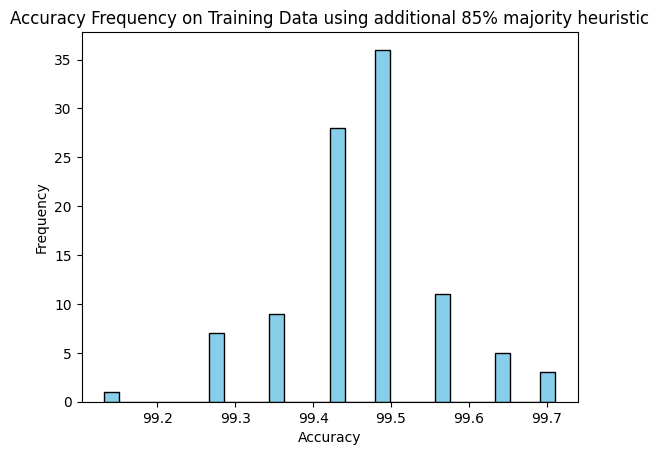

Accuracy - Training Data using additional 85% majority heuristic
Mean Accuracy: 99.46
Standard Deviation of Accuracy: 0.10


In [16]:
plot_histograms(train_accs_additional_criterion, 'Accuracy Frequency on Training Data using additional 85% majority heuristic')
get_stats(train_accs_additional_criterion, "Accuracy - Training Data using additional 85% majority heuristic")

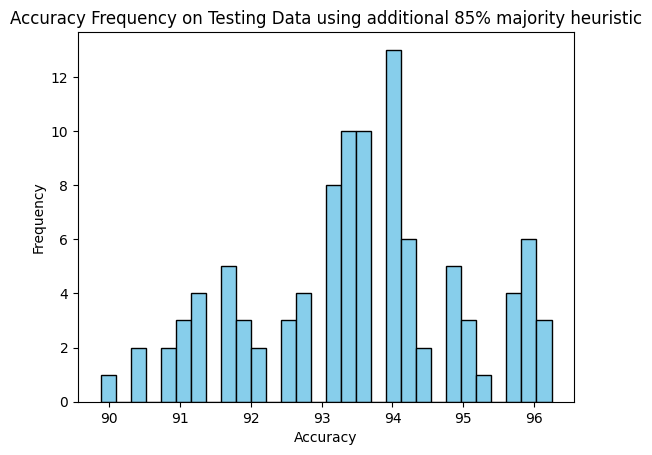

Accuracy - Testing Data using additional 85% majority heuristic
Mean Accuracy: 93.49
Standard Deviation of Accuracy: 1.50


In [17]:
plot_histograms(test_accs_additional_criterion, 'Accuracy Frequency on Testing Data using additional 85% majority heuristic')
get_stats(test_accs_additional_criterion, "Accuracy - Testing Data using additional 85% majority heuristic")